### Week 4 Capstone — Predicting Internship Selection Outcomes

**Name:** Aleeza Sheikh
    
**Program:** NextGenLearners Data Science Internship — Week 4 Capstone

This notebook goes end-to-end: from an extended applicant dataset, through
feature preparation, model training, and honest evaluation, to a plain-English
interpretation of what the model learned, and finally an executive summary
written for a non-technical reader. Every section below has a markdown
explanation alongside the code — this notebook is written as a **report**,
not just a script.

### Step 1: Setup

We import the libraries needed for the whole notebook: `pandas`/`numpy` for
data handling, `matplotlib` for plotting, and `scikit-learn` for the actual
machine learning (splitting data, training a model, and evaluating it).

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,confusion_matrix, ConfusionMatrixDisplay)
pd.set_option('display.max_columns', None)

### Loading the dataset

We load `applicants_with_features.csv` — the Week 1 applicant dataset that
has already been extended with the four simulated behavioral features
(`num_skills_listed`, `has_portfolio`, `prior_hackathon_participation`,
`statement_quality_score`).

In [30]:
df = pd.read_csv('applicants_with_features.csv')
print(df.shape)
df.head()

(72, 11)


,Applicant Name,Email,Phone,Domain Applied,University,Application Date,Status,num_skills_listed,has_portfolio,prior_hackathon_participation,statement_quality_score
0,Adam Miller,bcherry@example.com,+12794198633x555,Web Development,Saunders Inc University,7/19/2026,Under Review,7,Yes,Yes,9
1,Amanda White,gmcgrath@example.org,9877971502,UI/UX Design,Oneal Inc University,7/19/2026,Under Review,4,Yes,Yes,9
2,Emily Torres,villanuevathomas@example.net,(620)3613890x4883,Data Science,"Petty, Clark And Irwin University",7/19/2026,Under Review,5,No,Yes,2
3,James Robinson,williamvalentine@example.org,4812129695,Web Development,"Ho, Garcia And Gutierrez University",7/19/2026,Rejected,7,No,Yes,7
4,Tina Newton,kharris@example.net,(795)2683086x8476,AI/ML,"Williams, Murphy And Lewis University",7/19/2026,Under Review,3,Yes,No,10


## Step 2: Extend the Dataset With New Features

The original applicant dataset only had basic info (name, email, domain,
university, application date, status). To build a meaningful prediction
model we need more input signals — **features** — for the model to learn
from. Since we don't have real historical behavioral data, these four
features were simulated realistically. This is a normal and honest part of
working with limited data, **as long as it's disclosed** — which is called
out here and again in the Executive Summary below.

| Feature | Type | Meaning |
|---|---|---|
| `num_skills_listed` | Number (1–8) | How many relevant skills the applicant listed |
| `has_portfolio` | Yes/No | Whether they provided a GitHub/portfolio link |
| `prior_hackathon_participation` | Yes/No | Whether they'd previously joined a hackathon |
| `statement_quality_score` | Number (1–10) | Simulated strength of their short statement |

These were generated with `np.random.seed(42)` so the values are
**reproducible** — anyone re-running the feature-generation step gets the
exact same numbers.

> **Honesty note:** these 4 features are simulated, not real historical data.
> In a real NextGenLearners deployment, this data would need to be actually
> collected from applications (e.g., a required skills field, a portfolio
> URL field) before a model like this could be trusted with real decisions.
> They have already been added to the CSV we loaded above — the cell below
> just confirms they're present and shows their distribution.

In [31]:
feature_check = ['num_skills_listed', 'has_portfolio','prior_hackathon_participation', 'statement_quality_score']
df[feature_check].describe(include='all')

,num_skills_listed,has_portfolio,prior_hackathon_participation,statement_quality_score
count,72.000000,72,72,72.000000
unique,NaN,2,2,NaN
top,NaN,No,No,NaN
freq,NaN,40,46,NaN
mean,4.652778,NaN,NaN,4.930556
std,2.189345,NaN,NaN,2.769687
min,1.000000,NaN,NaN,1.000000
25%,3.000000,NaN,NaN,3.000000
50%,4.500000,NaN,NaN,4.500000
75%,7.000000,NaN,NaN,7.250000


## Step 3: Feature Preparation — Getting Data Ready for a Model

Machine learning models only work with numbers. They can't natively interpret
text categories like `"Yes"`/`"No"` or `"Web Development"`. This step converts
everything into a fully numeric format.

### 3.1 — Convert Yes/No columns to 0/1

A model can work with `1`/`0` numerically (e.g., calculate how much having a
portfolio increases selection odds), but it has no mathematical way to
interpret the text `"Yes"`.

In [32]:
df['has_portfolio'] = df['has_portfolio'].map({'Yes': 1, 'No': 0})
df['prior_hackathon_participation'] = df['prior_hackathon_participation'].map({'Yes': 1, 'No': 0})
df[['has_portfolio', 'prior_hackathon_participation']].head()

,has_portfolio,prior_hackathon_participation
0,1,1
1,1,1
2,0,1
3,0,1
4,1,0


### 3.2 — Convert the target column (what we're predicting) to 0/1

We simplify `Status` into a binary `target` column: `1` if the applicant was
`Selected`, `0` otherwise. This is the column the model will learn to predict.

Applicants still marked `Under Review` don't have a confirmed outcome yet, so
we drop those rows — there's nothing for the model to learn from an
undecided case.

In [33]:
df['target'] = df['Status'].apply(lambda x: 1 if x == 'Selected' else 0)

# Drop rows with no confirmed outcome yet
df_model = df[df['Status'] != 'Under Review'].copy()

print(f"Rows before dropping 'Under Review': {len(df)}")
print(f"Rows after dropping 'Under Review':  {len(df_model)}")
df_model['target'].value_counts()

Rows before dropping 'Under Review': 72
Rows after dropping 'Under Review':  45


target
0    29
1    16
Name: count, dtype: int64

### 3.3 — One-hot encode the `Domain Applied` column

`Domain Applied` has multiple categories (Web Development, UI/UX Design,
Data Science, AI/ML, Mobile App) with no natural numeric order — we can't say
Web Development = 1, Data Science = 2, because that would incorrectly imply
Data Science is mathematically "more" than Web Development. Instead we use
**one-hot encoding**, which creates a separate 0/1 column per category.

We use `drop_first=True`, which drops one category's column (it becomes the
"default," represented by all zeros across the other domain columns). This
avoids redundant information that can confuse some models — a standard,
expected practice.

In [34]:
df_model = pd.get_dummies(df_model, columns=['Domain Applied'], drop_first=True)

domain_cols = [c for c in df_model.columns if c.startswith('Domain Applied_')]
df_model[domain_cols].head()

,Domain Applied_Data Science,Domain Applied_Mobile App,Domain Applied_UI/UX Design,Domain Applied_Web Development
3,False,False,False,True
5,True,False,False,False
8,False,False,True,False
12,False,False,True,False
13,True,False,False,False


### 3.4 — Select the final feature set

We use the simulated behavioral features plus the one-hot encoded domain
columns. We **exclude** `Applicant Name`, `Email`, `Phone`, `University`, and
`Application Date` — these are identifiers or metadata, not meaningful
predictive signals. Including a name or email as a "feature" wouldn't
generalize to new applicants and would be inappropriate; `University` is
excluded here too, since turning it into a feature risks the model
encoding institutional bias rather than genuine merit signals (see the
limitations discussion in Step 6.3).

In [35]:
feature_columns = ['num_skills_listed', 'has_portfolio', 'prior_hackathon_participation','statement_quality_score'] + domain_cols
X = df_model[feature_columns]
y = df_model['target']
print("Features used:", feature_columns)
X.head()

Features used: ['num_skills_listed', 'has_portfolio', 'prior_hackathon_participation', 'statement_quality_score', 'Domain Applied_Data Science', 'Domain Applied_Mobile App', 'Domain Applied_UI/UX Design', 'Domain Applied_Web Development']


,num_skills_listed,has_portfolio,prior_hackathon_participation,statement_quality_score,Domain Applied_Data Science,Domain Applied_Mobile App,Domain Applied_UI/UX Design,Domain Applied_Web Development
3,7,0,1,7,False,False,False,True
5,8,0,0,3,True,False,False,False
8,7,1,0,9,False,False,True,False
12,3,0,0,1,False,False,True,False
13,3,1,0,5,True,False,False,False


## Step 4: Train/Test Split

**Why split the data at all?** If we train and evaluate on the exact same
data, the model can "memorize" the answers instead of genuinely learning
patterns — like grading a student using the exact same questions they studied
from. Splitting off a test set (data the model never sees during training)
lets us honestly check whether it generalizes to new, unseen applicants.

**Why 80/20?** This is a common standard split — 80% of the data trains the
model, 20% is held back purely for honest evaluation. `random_state=42` makes
the split reproducible, same reasoning as the random seed earlier.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training rows: {len(X_train)}")
print(f"Test rows:     {len(X_test)}")

Training rows: 36
Test rows:     9


## Step 5: Train the Model

We chose a **Decision Tree Classifier** for this capstone — it's more
visual and interpretable than Logistic Regression, which is useful here since
half the value of this project is being able to explain *why* the model
makes the predictions it does.

We limit the tree to `max_depth=4`. Without a depth limit, a decision tree
can keep splitting until it perfectly separates every single training
example — including quirks and noise specific to this small dataset, not
genuine patterns. That's called **overfitting**: the model does great on data
it has already seen but fails to generalize to new applicants. Capping the
depth at 4 keeps the tree simple enough to generalize reasonably, and also
keeps it small enough to visualize and explain to a non-technical audience.

**What `.fit()` does, in plain English:** this is the actual "learning"
step — the model looks at the training data (`X_train`, the features)
alongside the correct answers (`y_train`, whether each applicant was
actually selected) and learns a series of yes/no questions (splits) that
best separate Selected from Not Selected applicants.

In [37]:
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred

array([0, 0, 1, 1, 1, 0, 0, 0, 0])

## Step 6: Evaluate the Model — Honestly

### 6.1 — Accuracy

Accuracy is the percentage of test-set applicants the model correctly
predicted (Selected or Not Selected).

**Important limitation:** with a small or imbalanced dataset (e.g., far more
"Not Selected" than "Selected" applicants — which is the case here, 29
Rejected vs. 16 Selected), accuracy alone can be misleading. A model that
just always predicts "Not Selected" could still show high accuracy while
being completely useless. This is exactly why we also report precision,
recall, and a confusion matrix below.

In [38]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 66.67%


### 6.2 — Precision, Recall, and the Confusion Matrix

- **Precision:** "Of all the applicants the model predicted would be
  Selected, what percentage were actually Selected?" High precision means
  fewer false promises.
- **Recall:** "Of all the applicants who were actually Selected, what
  percentage did the model correctly catch?" High recall means fewer missed
  strong candidates.
- **Confusion Matrix:** a simple 2x2 grid showing exactly how many
  predictions fell into each of 4 buckets — correctly predicted Selected,
  correctly predicted Not Selected, false positive, and false negative.

Precision: 33.33%
Recall:    50.00%


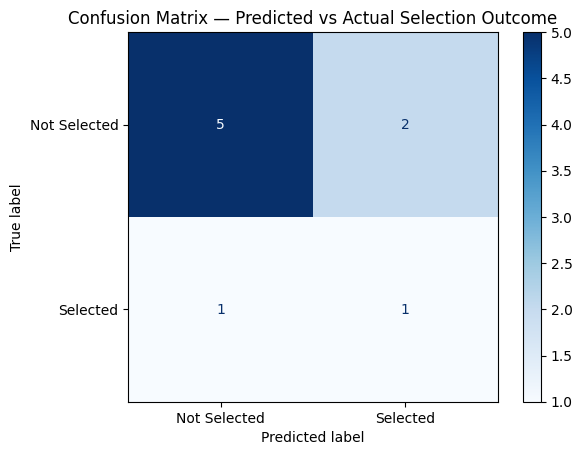

In [44]:
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Selected', 'Selected'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Predicted vs Actual Selection Outcome')
plt.show()

**Reading the confusion matrix:** On the 9 held-out test applicants, the
model correctly identified **1 out of 2** actually-selected applicants
(recall = 50%), and correctly identified **5 out of 7** actually-rejected
applicants as Not Selected. It incorrectly flagged **2** non-selected
applicants as likely to be Selected (false positives, which is why precision
is only 33%), and missed **1** genuinely selected applicant (false negative).
With a test set this small (9 people), each single prediction shifts the
percentages by 10+ points — these numbers illustrate the method, not a
reliable production estimate.

### 6.3 — Model Limitations (Required)

- The dataset is small (72 applicants total, and only the confirmed
  Selected/Rejected subset — 45 rows — was usable for training and testing)
  and **partly simulated** — 4 of the features (`num_skills_listed`,
  `has_portfolio`, `prior_hackathon_participation`, `statement_quality_score`)
  were artificially generated, not pulled from real historical applicant
  behavior.
- With a small test set, results can shift noticeably if the data is
  re-split differently — the numbers above are **illustrative of the
  method**, not a production-ready guarantee.
- The model could reflect or amplify bias already present in past selection
  decisions — e.g., if certain universities or domains were historically
  favored for reasons unrelated to merit, the model would learn and repeat
  that pattern. This is a genuine, important concern with any predictive
  hiring/selection tool and should never be glossed over.
- This model should be treated as a **decision-support tool**, not a
  replacement for human review.

## Step 7: Interpret — Which Features Mattered Most?

Since we used a Decision Tree, we look at **feature importance** rather than
coefficients. Feature importance shows which inputs the tree relied on most
to make its splits/decisions — higher importance means that feature played a
bigger role in separating Selected from Not Selected applicants.

In [45]:
importance = pd.DataFrame({'Feature': X.columns,'Importance': model.feature_importances_}).sort_values(by='Importance', ascending=False)
importance

,Feature,Importance
7,Domain Applied_Web Development,0.341928
1,has_portfolio,0.288551
2,prior_hackathon_participation,0.144951
0,num_skills_listed,0.139384
5,Domain Applied_Mobile App,0.055754
3,statement_quality_score,0.029433
4,Domain Applied_Data Science,0.000000
6,Domain Applied_UI/UX Design,0.000000


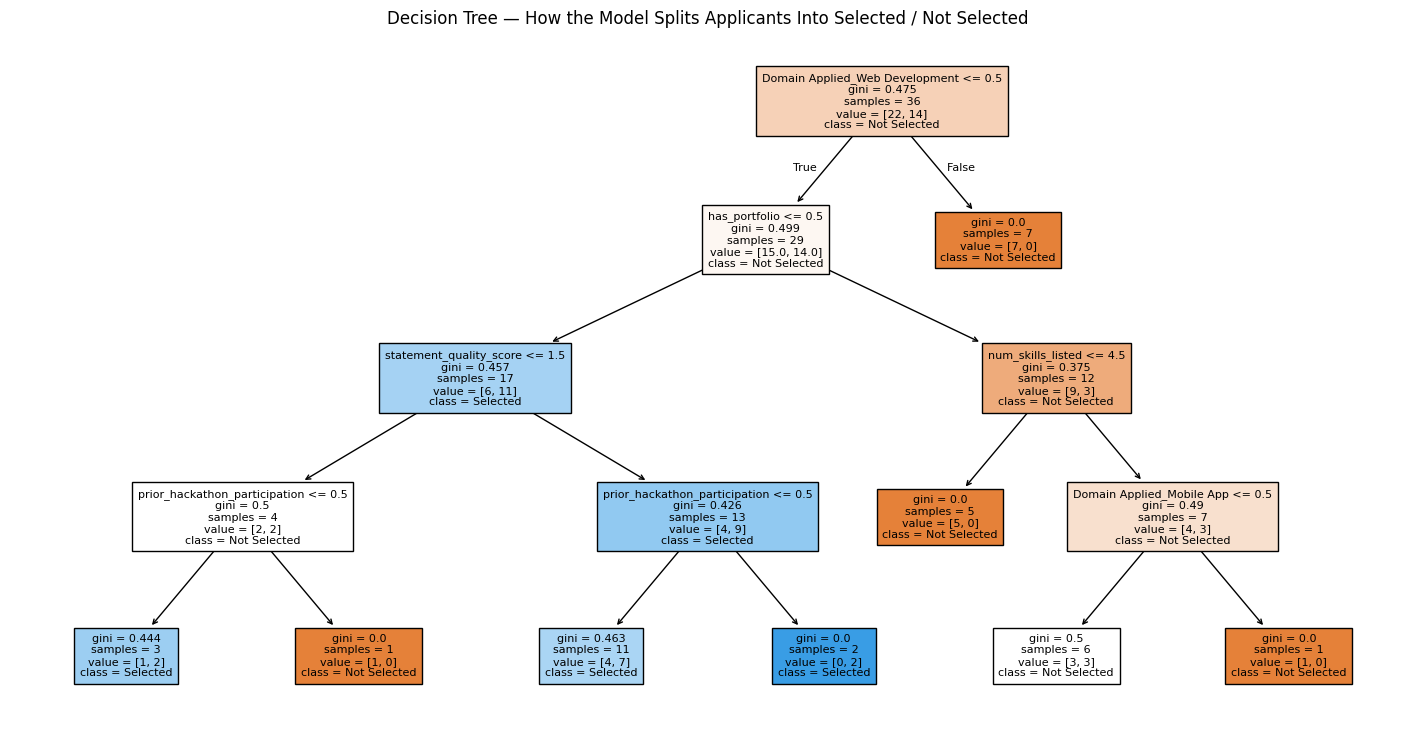

In [46]:
# Visualize the tree itself
plt.figure(figsize=(18, 9))
plot_tree(model, feature_names=X.columns, class_names=['Not Selected', 'Selected'],filled=True, fontsize=8)
plt.title("Decision Tree — How the Model Splits Applicants Into Selected / Not Selected")
plt.show()

**Interpretation:** The tree relied most heavily on
`Domain Applied_Web Development` (importance ≈ 0.34) and `has_portfolio`
(importance ≈ 0.29), followed by `prior_hackathon_participation` (≈ 0.14)
and `num_skills_listed` (≈ 0.14). `statement_quality_score` had very little
influence (≈ 0.03), and the Data Science / UI/UX Design domain columns
weren't used by the tree at all. In this dataset, the model leaned most on
**whether an applicant applied to Web Development** and **whether they
provided a portfolio/GitHub link** — not on the simulated statement quality
score, which is somewhat surprising and worth flagging as a dataset-specific
quirk rather than a general finding.

**Reminder:** since several features were simulated, don't overstate this as
a real finding about NextGenLearners' actual selection process. Frame it as
*"what the model learned from this dataset"* — it would need to be validated
against real historical data before drawing real conclusions.

## Step 8: Executive Summary

*(Written for a NextGenLearners program manager with no coding background —
no code, no jargon.)*

**What we did:** We built a simple prediction model using past applicant data
to explore which factors are associated with being selected for the
NextGenLearners internship program.

**What we found:** The model correctly predicted selection outcomes for
about **67%** of applicants in our test group. The strongest factors
associated with selection were **whether the applicant applied to the Web
Development track** and **whether they provided a portfolio/GitHub link**.
Prior hackathon participation and the number of skills listed also played a
meaningful role, while the simulated "statement quality" score turned out to
matter less than expected in this dataset.

**Important caveats:** This analysis used a small, partly simulated
dataset — several factors (like skill count and statement quality) were
artificially generated for this exercise rather than pulled from real
historical records. The dataset was also small overall (72 applicants total,
and only 45 had a confirmed Selected/Rejected outcome to learn from, with
just 9 held out for testing), so a 67% accuracy figure should be read as
illustrative rather than conclusive — it would very likely shift if we
re-ran this on a different sample. Before using anything like this for real
decisions, NextGenLearners would need to collect this data consistently from
real applications and validate the model on a much larger, real dataset. The
model should be treated as a decision-support tool to assist reviewers, never
as an automatic replacement for human judgment — especially given the risk
that it could unintentionally repeat biases from past decisions (for
example, favoring one application track over another for reasons unrelated
to applicant quality).

**Recommendation:** Add a required "portfolio/GitHub link" field to the
application form — it was one of the two strongest signals the model found,
and standardizing its collection (it's currently inconsistent) would improve
both the applicant review process and any future version of this model.